# Spilling End-to-End Benchmark Results

Figures for the spill subsystem: does spilling window slices under memory pressure keep a query
alive at a memory budget where it would otherwise die, and does a **predictive** policy — keep the
slices the watermark predictor says are about to trigger, spill the rest — beat a purely
**reactive** pressure-only policy?

VLDB/SIGMOD-style figures. Hue is always the *spill variant*; every other knob is a facet or an
axis. Run this notebook from the benchmark directory (`scripts/benchmarking/spilling_e2e_benchmarks`)
— the loader globs a relative `results/`.

```
pip install -r requirements.txt
```

## Reading the sweep

One row of `results.csv` is one **cell**: a fresh worker running four windowed self-joins
concurrently (windows 1s/1s, 5s/5s, 10s/2s, 30s/5s), fed by two Rust TCP generators per query.

| Column | Meaning |
|---|---|
| `threads` | worker threads (1 / 4 / 8) |
| `operator_buffer_size`, `no_buffers` | the **memory budget**: pool size = `no_buffers × operator_buffer_size` |
| `spill_variant` | `off`, `reactive-mem`, `reactive-file`, `predictive-mem`, `predictive-file` |
| `predictor` | `ewma` / `kalman`, only for the predictive policy |
| `high_bound` | memory-pressure ratio at/above which the policy spills |
| `horizon_ms` | predictive policy: keep-resident look-ahead |
| `var_sized_bytes` | payload bytes in the VARSIZED column — drives per-slice state size |
| `ingestion_rate` | tuples/s per source; `0` = unbounded |

Measured per cell: `avg_throughput_tps`, `peak_rss_bytes`, `peak_pooled_used`/`peak_unpooled_used`,
and the spill counters (`total_spills`, `total_restores`, `spilled_bytes`, `kept_by_prediction`,
`avg_restore_latency_ms`, …). `sinks_nonempty` is the correctness gate — every cell must produce
output, otherwise its throughput number means nothing.

Per cell there are also three time series, loaded on demand:
`memory.csv` (`normalized_timestamp_ms, rss_bytes, pooled_used, unpooled_used`),
`throughput.csv` (`normalized_timestamp_ms, query_id, throughput_tps`) and
`spill_stats.csv` (per slice store, cumulative counters).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

### Pin RESULTS_CSV to compare a specific run; None picks the newest results/<run-id>/results.csv.
RESULTS_CSV = None
if RESULTS_CSV is None:
    candidates = sorted(Path('results').glob('*/results.csv'))
    if not candidates:
        raise FileNotFoundError('no results/<run-id>/results.csv — run benchmark.py first')
    RESULTS_CSV = candidates[-1]
RUN_DIR = Path(RESULTS_CSV).parent
FIG_DIR = RUN_DIR
print('run:', RUN_DIR)

df = pd.read_csv(RESULTS_CSV)

NUMERIC = ['threads', 'operator_buffer_size', 'no_buffers', 'high_bound', 'horizon_ms',
           'var_sized_bytes', 'ingestion_rate', 'wall_s', 'sinks_nonempty', 'avg_throughput_tps',
           'throughput_samples', 'peak_rss_bytes', 'peak_pooled_used', 'peak_unpooled_used',
           'total_spills', 'total_restores', 'total_spill_failures', 'spilled_bytes',
           'restored_bytes', 'kept_by_prediction', 'spilled_predictor_cold',
           'spilled_beyond_horizon', 'avg_spill_latency_ms', 'avg_restore_latency_ms',
           'max_restore_latency_ms', 'peak_spilled_slices', 'spill_stats_samples']
for c in NUMERIC:
    if c in df:
        df[c] = pd.to_numeric(df[c], errors='coerce')
### astype(str) after fillna: a column that is empty in every row is read as float64, and both the
### .str accessor below and the variant label above need real strings.
df['predictor'] = df.get('predictor', pd.Series(dtype=object)).fillna('').astype(str)
df['failure_reason'] = df['failure_reason'].fillna('').astype(str)
df['failed'] = df['failure_reason'].str.len() > 0


def variant(row):
    '''Display label for the spill configuration: policy-backend, plus the predictor when there is one.'''
    name = row['spill_variant']
    pred = str(row['predictor'])
    return f'{name}/{pred}' if pred else name


### Fixed order, so a facet that happens to contain fewer variants does NOT repaint the survivors:
### colour tracks the configuration, never its rank within a subplot.
VARIANT_ORDER = ['off', 'reactive-mem', 'reactive-file',
                 'predictive-mem/ewma', 'predictive-mem/kalman',
                 'predictive-file/ewma', 'predictive-file/kalman']
df['variant'] = df.apply(variant, axis=1)
present = [v for v in VARIANT_ORDER if v in set(df['variant'])]
extra = sorted(set(df['variant']) - set(VARIANT_ORDER))
VARIANT_ORDER = present + extra          # unknown variants keep a stable slot at the end
df['variant'] = pd.Categorical(df['variant'], categories=VARIANT_ORDER, ordered=True)

df['policy'] = df['spill_variant'].map(lambda s: 'off' if s == 'off' else s.split('-')[0])
df['backend'] = df['spill_variant'].map(
    lambda s: '—' if s == 'off' else ('in-memory' if s.endswith('-mem') else 'local-file'))

df['tps_M'] = df['avg_throughput_tps'] / 1e6
df['peak_rss_gib'] = df['peak_rss_bytes'] / 2**30
df['spilled_gib'] = df['spilled_bytes'] / 2**30
### Pool bytes actually configured for this cell — the "memory budget" axis of the headline figure.
df['budget_mib'] = df['no_buffers'] * df['operator_buffer_size'] / 2**20

### Every cell has exactly one `off` twin: same everything except the spill configuration. Ratios
### against it separate "spilling helps" from "this cell is just faster".
BASE_KEY = ['threads', 'operator_buffer_size', 'no_buffers', 'var_sized_bytes', 'ingestion_rate']
base = (df[df['spill_variant'] == 'off']
        .groupby(BASE_KEY, as_index=False)[['avg_throughput_tps', 'peak_rss_bytes']]
        .mean()
        .rename(columns={'avg_throughput_tps': 'base_tps', 'peak_rss_bytes': 'base_rss'}))
df = df.merge(base, on=BASE_KEY, how='left')
df['speedup'] = df['avg_throughput_tps'] / df['base_tps']
df['mem_ratio'] = df['peak_rss_bytes'] / df['base_rss']

ok = df[~df['failed']].copy()
THREADS = sorted(df['threads'].dropna().astype(int).unique())
BUDGETS = sorted(df['no_buffers'].dropna().astype(int).unique())

_series_cache = {}


def series(cell_slug, name):
    '''Load one per-cell time series (memory / throughput / spill_stats). Empty frame if absent.'''
    key = (cell_slug, name)
    if key not in _series_cache:
        p = RUN_DIR / cell_slug / f'{name}.csv'
        _series_cache[key] = pd.read_csv(p) if p.exists() else pd.DataFrame()
    return _series_cache[key]


def have(frame, what):
    '''Guard for figures that need data a given run may not contain. Prints instead of raising, so
    a partial sweep still executes the whole notebook top to bottom.'''
    if len(frame) == 0:
        print(f'skipped: no rows for {what}')
        return False
    return True


print(f'cells: {len(df)} | failed: {int(df["failed"].sum())} | variants: {VARIANT_ORDER}')
ok.head()

run: results/20260803-152858
cells: 11 | failed: 0 | variants: ['off', 'reactive-mem', 'reactive-file', 'predictive-mem/ewma', 'predictive-mem/kalman', 'predictive-file/ewma', 'predictive-file/kalman']


,run_id,cell_slug,threads,operator_buffer_size,no_buffers,spill_variant,predictor,high_bound,horizon_ms,var_sized_bytes,...,policy,backend,tps_M,peak_rss_gib,spilled_gib,budget_mib,base_tps,base_rss,speedup,mem_ratio
0,20260803-152858,t4_bs4096_nb4096_off_v4096_rinf,4,4096,4096,off,,0.7,50,4096,...,off,—,0.040543,1.162712,0.000000,16.0,40542.928,1.248453e+09,1.000000,1.000000
1,20260803-152858,t4_bs4096_nb4096_reactive-mem_v4096_rinf,4,4096,4096,reactive-mem,,0.7,50,4096,...,reactive,in-memory,0.035564,14.693657,0.065736,16.0,40542.928,1.248453e+09,0.877194,12.637399
2,20260803-152858,t4_bs4096_nb4096_reactive-file_v4096_rinf,4,4096,4096,reactive-file,,0.7,50,4096,...,reactive,local-file,0.034125,10.137283,0.039440,16.0,40542.928,1.248453e+09,0.841703,8.718653
3,20260803-152858,t4_bs4096_nb4096_predictive-mem-ewma_v4096_rin...,4,4096,4096,predictive-mem,ewma,0.7,50,4096,...,predictive,in-memory,0.034797,1.361588,0.003283,16.0,40542.928,1.248453e+09,0.858272,1.171044
4,20260803-152858,t4_bs4096_nb4096_predictive-mem-ewma_v4096_rin...,4,4096,4096,predictive-mem,ewma,0.7,500,4096,...,predictive,in-memory,0.030186,1.112568,0.000082,16.0,40542.928,1.248453e+09,0.744543,0.956873


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# VLDB / SIGMOD camera-ready style: serif, compact, no chartjunk.
# Identical to the watermark-predictor and slice-optimization notebooks, so the three figure sets
# sit side by side in one paper without a visual seam.
sns.set_theme(context='paper', style='whitegrid', font='serif')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'legend.fontsize': 9,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
})
# Keyed by variant NAME, not by position, so every figure paints the same configuration the same
# colour even when it plots a subset. tab10 for the same reason as the sibling notebooks: the muted
# 'colorblind' set collapses the same-family variants (2x reactive, 4x predictive) into one blur.
PALETTE = dict(zip(VARIANT_ORDER, sns.color_palette('tab10', max(len(VARIANT_ORDER), 3))))
MARKERS = dict(zip(VARIANT_ORDER, ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>'][:len(VARIANT_ORDER)]))


def order_for(frame):
    '''Hue order restricted to the variants a subset actually contains. Passing the full VARIANT_ORDER
    to a subset makes seaborn emit legend entries for series that are not in the panel; PALETTE is
    keyed by name, so dropping them does not change any colour.'''
    have_ = set(frame['variant'].dropna().astype(str))
    return [v for v in VARIANT_ORDER if v in have_]


def save(fig, name):
    '''Write the figure next to the run's results.csv. The sibling notebooks historically had no
    savefig at all and their PNGs were hand-extracted cell outputs; these regenerate.'''
    out = FIG_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight')
    print('wrote', out)


def legend_below(ax, ncol=None, title='variant'):
    ax.legend(title=title, loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=ncol or min(len(VARIANT_ORDER), 4))


def legend_top(fig, src, title=None, ncol=4, pad=0.012):
    '''Horizontal legend strip between the figure title and the axes. Owns the whole top band —
    pass the figure title HERE rather than calling fig.suptitle, and do not use tight_layout.'''
    if hasattr(src, 'get_legend_handles_labels'):
        handles, labels = src.get_legend_handles_labels()
        if src.get_legend():
            src.get_legend().remove()
    else:
        handles, labels = src
    fig.canvas.draw()
    leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.0),
                     ncol=ncol, frameon=False, fontsize=9)
    fig.canvas.draw()
    lh = leg.get_window_extent().transformed(fig.transFigure.inverted()).height
    st_h = 0.05 if title else 0.0
    ath = 0.05 if any(ax.get_title() for ax in fig.axes) else 0.0
    fig.subplots_adjust(top=1.0 - lh - st_h - ath - 2 * pad)
    leg.set_bbox_to_anchor((0.5, 1.0 - st_h - pad), transform=fig.transFigure)
    if title:
        fig.suptitle(title, y=1.0 - pad, va='top')


print('style ready |', len(PALETTE), 'variants')

style ready | 7 variants


## 0. Did the sweep actually run?

Before any performance claim: how many cells completed, why the rest did not, and — the one that
matters for correctness — did every surviving cell write output to all four sinks? A cell with an
empty sink produced a throughput number for a query that emitted nothing.

wrote results/20260803-152858/fig_00_completeness.png


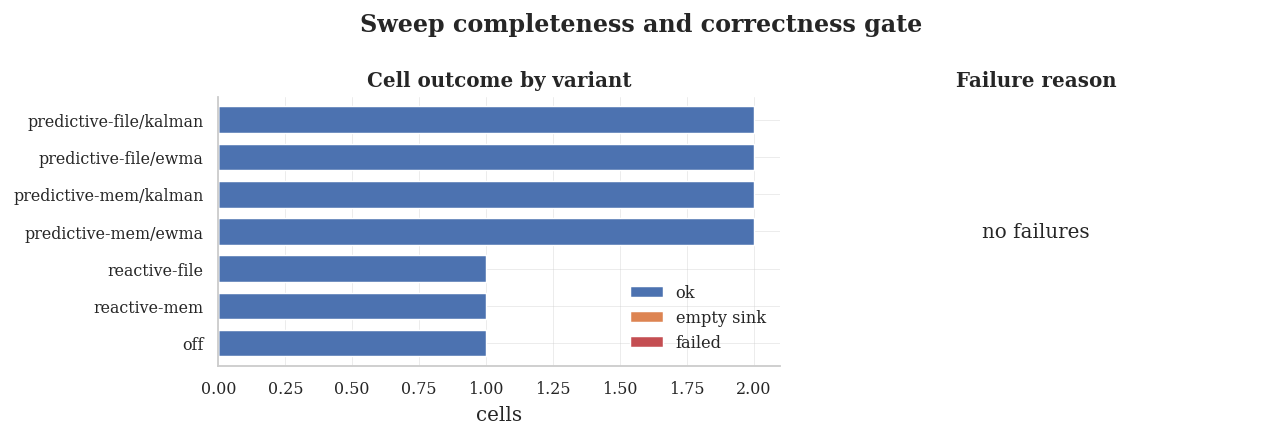

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={'width_ratios': [1.2, 1]})

status = (df.assign(status=np.where(df['failed'], 'failed',
                                    np.where(df['sinks_nonempty'] == 1, 'ok', 'empty sink')))
            .groupby(['variant', 'status'], observed=True).size().rename('cells').reset_index())
piv = status.pivot(index='variant', columns='status', values='cells').fillna(0)
for col, colour in [('ok', '#4c72b0'), ('empty sink', '#dd8452'), ('failed', '#c44e52')]:
    if col not in piv:
        piv[col] = 0
piv = piv[['ok', 'empty sink', 'failed']]
piv.plot(kind='barh', stacked=True, ax=axes[0], width=0.72,
         color=['#4c72b0', '#dd8452', '#c44e52'], legend=True)
axes[0].set_xlabel('cells')
axes[0].set_ylabel('')
axes[0].set_title('Cell outcome by variant')
axes[0].legend(title='', loc='lower right')

### astype(str), not fillna(''): when no cell failed the selection is an EMPTY float64 Series and
### the .str accessor raises on it. Exception messages carry paths and pids, so group by type prefix.
reasons = df.loc[df['failed'], 'failure_reason'].astype(str)
reasons = reasons.str.split(':').str[0].value_counts()
if len(reasons):
    axes[1].barh(reasons.index[::-1], reasons.to_numpy()[::-1], color='#c44e52', height=0.6)
    axes[1].set_xlabel('cells')
else:
    axes[1].text(0.5, 0.5, 'no failures', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()
axes[1].set_title('Failure reason')

fig.suptitle('Sweep completeness and correctness gate', fontweight='bold')
fig.tight_layout()
save(fig, 'fig_00_completeness')
plt.show()

if (df['sinks_nonempty'] == 0).any():
    display(df.loc[df['sinks_nonempty'] == 0, ['cell_slug', 'variant', 'failure_reason']]
              .reset_index(drop=True))

## 1. Throughput vs memory budget — the headline

The claim spilling makes: as the buffer pool shrinks, a non-spilling engine degrades or dies, a
reactive spilling engine survives at a throughput cost, and a predictive one recovers most of that
cost by not evicting the slices it is about to need.

x is the memory budget (`no_buffers`, i.e. pool size at fixed buffer size), so **left is hard**.

Restricted to the highest thread count and the largest payload — the regime where per-slice state is
biggest and pressure arrives soonest. Mixing payload sizes into one line would average two different
populations and inflate the interval past the point of meaning; §10 varies payload explicitly.

wrote results/20260803-152858/fig_01_throughput_vs_budget.png


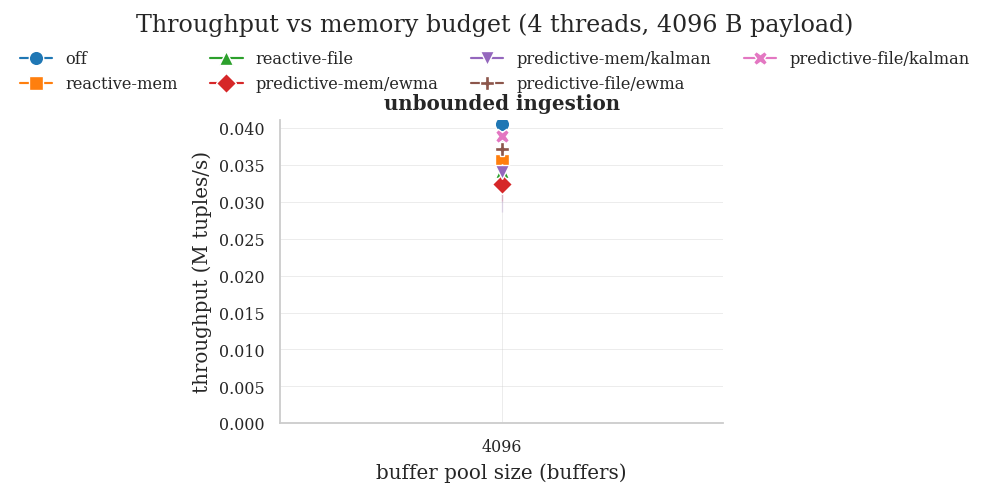

In [4]:
sub = ok[ok['avg_throughput_tps'].notna()]
sub = sub[(sub['threads'] == sub['threads'].max()) & (sub['var_sized_bytes'] == sub['var_sized_bytes'].max())]
if have(sub, 'throughput'):
    rates = sorted(sub['ingestion_rate'].dropna().unique())
    fig, axes = plt.subplots(1, len(rates), figsize=(4.4 * len(rates), 3.6),
                             sharey=True, squeeze=False)
    for ax, rate in zip(axes[0], rates):
        s = sub[sub['ingestion_rate'] == rate]
        sns.lineplot(data=s, x='no_buffers', y='tps_M', hue='variant', style='variant',
                     hue_order=order_for(s), palette=PALETTE, markers=MARKERS, dashes=False,
                     markersize=8, errorbar=('ci', 95), ax=ax)
        ax.set_xscale('log', base=2)
        ax.set_xticks(BUDGETS)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.set_title('unbounded ingestion' if rate == 0 else f'{rate/1e3:.0f}k tuples/s per source')
        ax.set_ylim(bottom=0)
        ax.set_xlabel('buffer pool size (buffers)')
        ax.set_ylabel('throughput (M tuples/s)')
        if ax.get_legend():
            ax.get_legend().remove()
    legend_top(fig, axes[0][0],
               f'Throughput vs memory budget ({int(sub["threads"].max())} threads, '
               f'{int(sub["var_sized_bytes"].max())} B payload)')
    save(fig, 'fig_01_throughput_vs_budget')
    plt.show()

## 2. Does spilling actually bound memory?

Peak resident set and peak pooled-buffer occupancy. If the spill policy works, the spilling
variants must sit visibly below `off` at the same budget — otherwise the throughput cost in §1 buys
nothing.

wrote results/20260803-152858/fig_02_peak_memory.png


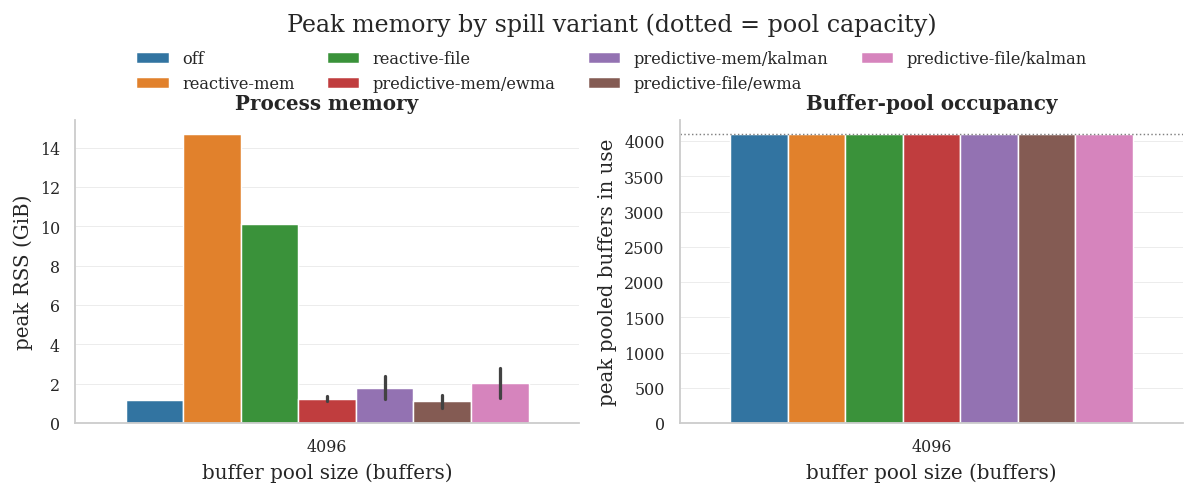

In [5]:
sub = ok[ok['peak_rss_bytes'].notna() & (ok['peak_rss_bytes'] > 0)]
if have(sub, 'memory peaks'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    sns.barplot(data=sub, x='no_buffers', y='peak_rss_gib', hue='variant',
                hue_order=order_for(sub), palette=PALETTE, errorbar=('ci', 95), ax=axes[0])
    axes[0].set_ylabel('peak RSS (GiB)')
    axes[0].set_xlabel('buffer pool size (buffers)')
    axes[0].set_title('Process memory')

    sns.barplot(data=sub, x='no_buffers', y='peak_pooled_used', hue='variant',
                hue_order=order_for(sub), palette=PALETTE, errorbar=('ci', 95), ax=axes[1])
    axes[1].set_ylabel('peak pooled buffers in use')
    axes[1].set_xlabel('buffer pool size (buffers)')
    axes[1].set_title('Buffer-pool occupancy')
    ### The pool is the resource the spill policy actually senses; the ceiling makes saturation legible.
    for b in BUDGETS:
        axes[1].axhline(b, ls=':', lw=0.8, color='0.5')
    for ax in axes:
        if ax.get_legend():
            ax.get_legend().remove()
    legend_top(fig, axes[0], 'Peak memory by spill variant (dotted = pool capacity)')
    save(fig, 'fig_02_peak_memory')
    plt.show()

## 3. The memory–throughput trade-off

Every cell as one point: memory it peaked at against the throughput it delivered. Upper-left is
better (less memory, more work). The staircase is the Pareto frontier — the configurations no other
configuration beats on both axes at once.

wrote results/20260803-152858/fig_03_pareto.png


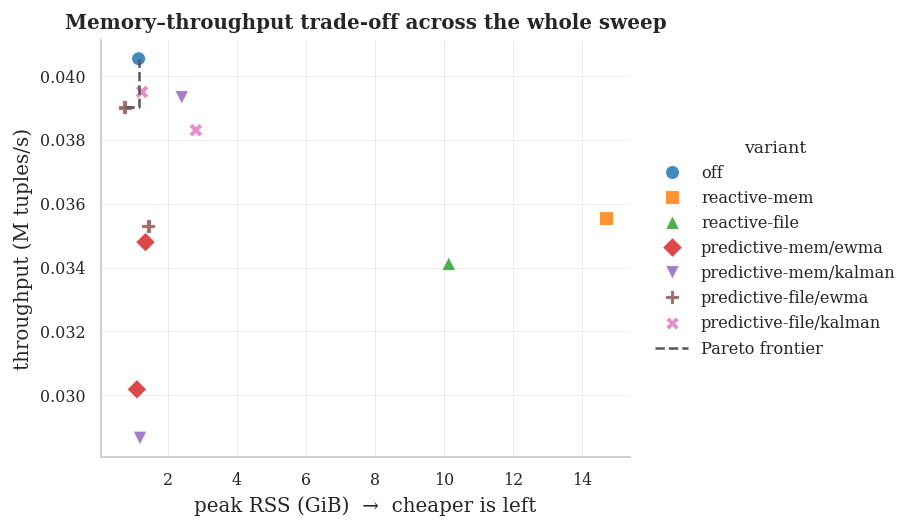

In [6]:
sub = ok[(ok['peak_rss_bytes'] > 0) & ok['avg_throughput_tps'].notna()]
if have(sub, 'pareto'):
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    sns.scatterplot(data=sub, x='peak_rss_gib', y='tps_M', hue='variant', style='variant',
                    hue_order=order_for(sub), palette=PALETTE, markers=MARKERS, s=60,
                    alpha=0.85, ax=ax)

    ### Frontier: sweep left-to-right in memory, keep a point only if nothing cheaper was faster.
    pts = sub[['peak_rss_gib', 'tps_M']].dropna().sort_values('peak_rss_gib')
    frontier, best = [], -np.inf
    for mem, tps in pts.to_numpy():
        if tps > best:
            frontier.append((mem, tps))
            best = tps
    if frontier:
        fx, fy = zip(*frontier)
        ax.step(fx, fy, where='post', color='0.35', lw=1.4, ls='--', zorder=1,
                label='Pareto frontier')
    ax.set_xlabel('peak RSS (GiB)  →  cheaper is left')
    ax.set_ylabel('throughput (M tuples/s)')
    ax.legend(title='variant', loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)
    ax.set_title('Memory–throughput trade-off across the whole sweep')
    fig.tight_layout()
    save(fig, 'fig_03_pareto')
    plt.show()

## 4. Memory over time

Peak memory is one number per cell and hides the shape. This overlays the per-cell `memory.csv` for
one matched configuration across variants: the sawtooth as windows fill and trigger, and whether
the policy clamps the envelope. Vertical rules mark the four query submissions (3 s apart).

matched cells: off=t4_bs4096_nb4096_off_v4096_rinf, reactive-mem=t4_bs4096_nb4096_reactive-mem_v4096_rinf, reactive-file=t4_bs4096_nb4096_reactive-file_v4096_rinf, predictive-mem/ewma=t4_bs4096_nb4096_predictive-mem-ewma_v4096_rinf_hz500, predictive-mem/kalman=t4_bs4096_nb4096_predictive-mem-kalman_v4096_rinf_hz500, predictive-file/ewma=t4_bs4096_nb4096_predictive-file-ewma_v4096_rinf_hz500, predictive-file/kalman=t4_bs4096_nb4096_predictive-file-kalman_v4096_rinf_hz500


wrote results/20260803-152858/fig_04_memory_timeseries.png


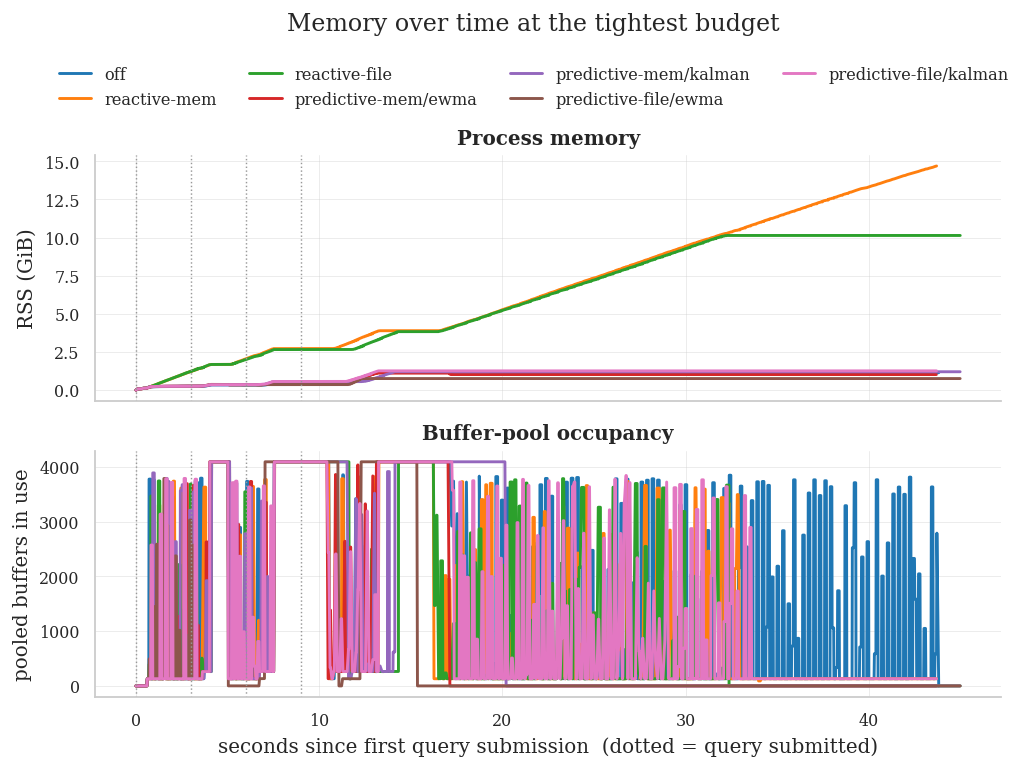

In [7]:
### Pick the tightest budget at the highest thread count — where the policy has to do something.
def matched_cells(frame, prefer_budget='min'):
    '''One cell per variant sharing every non-spill knob. Returns (label -> cell_slug).'''
    f = frame[frame['peak_rss_bytes'].notna()]
    if len(f) == 0:
        return {}
    budget = f['no_buffers'].min() if prefer_budget == 'min' else f['no_buffers'].max()
    f = f[f['no_buffers'] == budget]
    f = f[f['threads'] == f['threads'].max()]
    f = f[f['var_sized_bytes'] == f['var_sized_bytes'].max()]
    f = f[f['ingestion_rate'] == f['ingestion_rate'].min()]
    return {str(r['variant']): r['cell_slug'] for _, r in f.sort_values('variant').iterrows()}


picked = matched_cells(ok)
if not picked:
    print('skipped: no cell with memory samples')
else:
    print('matched cells:', json_dumps_compact := ', '.join(f'{k}={v}' for k, v in picked.items()))
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    for label, slug in picked.items():
        m = series(slug, 'memory')
        if len(m) == 0:
            continue
        t = m['normalized_timestamp_ms'] / 1000
        axes[0].plot(t, m['rss_bytes'] / 2**30, lw=1.6, label=label, color=PALETTE.get(label))
        axes[1].plot(t, m['pooled_used'], lw=1.6, label=label, color=PALETTE.get(label))
    for k in range(4):
        for ax in axes:
            ax.axvline(k * 3, ls=':', lw=0.8, color='0.6')
    axes[0].set_ylabel('RSS (GiB)')
    axes[1].set_ylabel('pooled buffers in use')
    axes[1].set_xlabel('seconds since first query submission  (dotted = query submitted)')
    axes[0].set_title('Process memory')
    axes[1].set_title('Buffer-pool occupancy')
    for ax in axes:
        if ax.get_legend():
            ax.get_legend().remove()
    legend_top(fig, axes[0], 'Memory over time at the tightest budget')
    save(fig, 'fig_04_memory_timeseries')
    plt.show()

## 5. Throughput over time

Where the spill cost lands. Each query is submitted 3 s after the previous one, so pressure builds
through the run; a reactive policy should show a visible dip when it starts evicting, and a
predictive one should dip less or later. Left: total across queries. Right: per query, so a large
window (30 s) can be told apart from a small one (1 s).

wrote results/20260803-152858/fig_05_throughput_timeseries.png


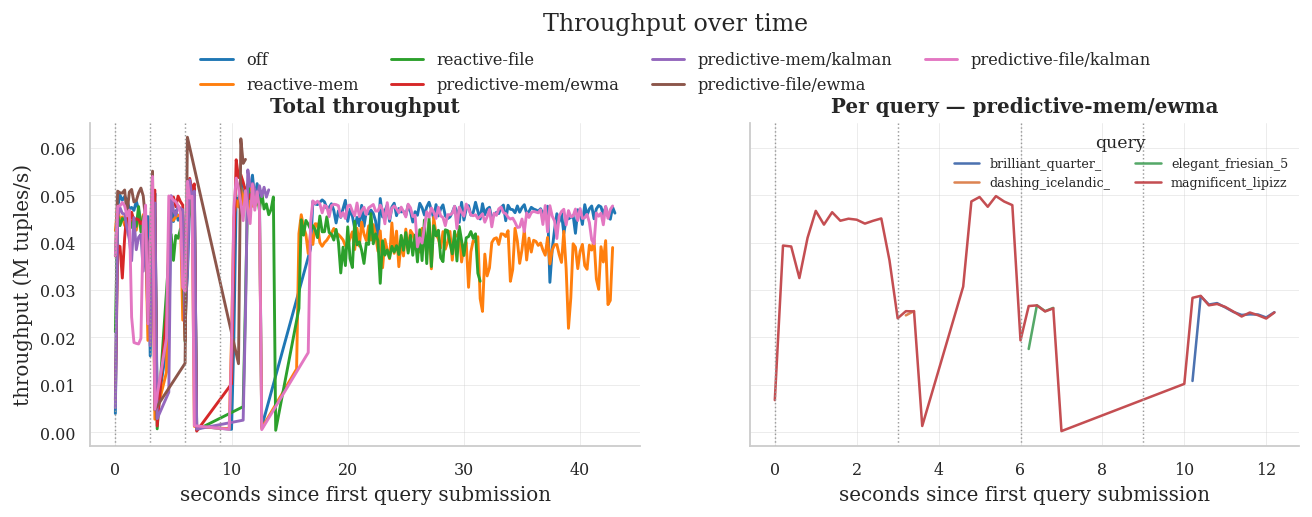

In [8]:
if not picked:
    print('skipped: no matched cells')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    for label, slug in picked.items():
        t = series(slug, 'throughput')
        if len(t) == 0:
            continue
        total = t.groupby('normalized_timestamp_ms')['throughput_tps'].sum()
        axes[0].plot(total.index / 1000, total.to_numpy() / 1e6, lw=1.6, label=label,
                     color=PALETTE.get(label))
    axes[0].set_title('Total throughput')
    axes[0].set_ylabel('throughput (M tuples/s)')

    ### Right panel: one variant, split per query — mixing variants and queries in one panel would
    ### need two colour channels for two different things.
    focus = next((lbl for lbl in picked if lbl.startswith('predictive')), next(iter(picked)))
    t = series(picked[focus], 'throughput')
    if len(t):
        for qid, g in t.groupby('query_id'):
            axes[1].plot(g['normalized_timestamp_ms'] / 1000, g['throughput_tps'] / 1e6,
                         lw=1.4, label=str(qid)[:18])
        axes[1].legend(title='query', fontsize=7, ncol=2)
    axes[1].set_title(f'Per query — {focus}')
    for ax in axes:
        ax.set_xlabel('seconds since first query submission')
        for k in range(4):
            ax.axvline(k * 3, ls=':', lw=0.8, color='0.6')
    if axes[0].get_legend():
        axes[0].get_legend().remove()
    legend_top(fig, axes[0], 'Throughput over time', ncol=4)
    save(fig, 'fig_05_throughput_timeseries')
    plt.show()

## 6. What does spilling cost when memory is *not* tight?

At the largest budget nothing needs to spill, so any throughput gap against `off` is the standing
overhead of having the subsystem enabled — the pressure sample per GC tick, the policy call per
slice, and for the predictive variants the predictor's `observe`/`predict`.

Bars are throughput relative to the matched `off` cell; 1.0 is parity.

wrote results/20260803-152858/fig_06_overhead.png


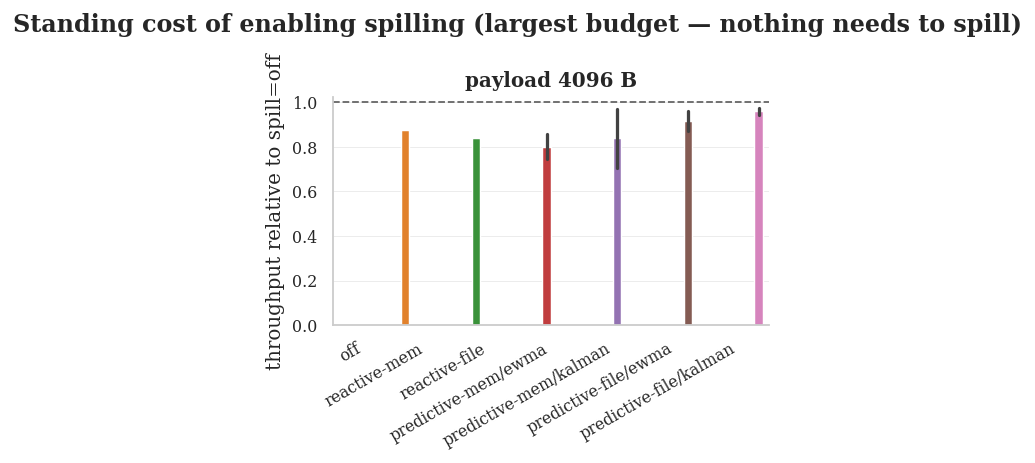

In [9]:
loose = ok[(ok['no_buffers'] == max(BUDGETS)) & ok['speedup'].notna() & (ok['spill_variant'] != 'off')]
if have(loose, 'overhead at the loosest budget'):
    sizes = sorted(loose['var_sized_bytes'].dropna().unique())
    fig, axes = plt.subplots(1, len(sizes), figsize=(4.2 * len(sizes), 3.6),
                             sharey=True, squeeze=False)
    for ax, size in zip(axes[0], sizes):
        s = loose[loose['var_sized_bytes'] == size]
        sns.barplot(data=s, x='variant', y='speedup', hue='variant', hue_order=order_for(s),
                    palette=PALETTE, errorbar=('ci', 95), legend=False, ax=ax)
        ax.axhline(1.0, ls='--', lw=1, color='0.4')
        ax.set_title(f'payload {int(size)} B')
        ax.set_xlabel('')
        ax.set_ylabel('throughput relative to spill=off')
        ax.tick_params(axis='x', rotation=30)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')
    fig.suptitle('Standing cost of enabling spilling (largest budget — nothing needs to spill)',
                 fontweight='bold')
    fig.tight_layout()
    save(fig, 'fig_06_overhead')
    plt.show()

## 7. Storage backend: in-memory vs local file

Holding the policy fixed and varying only where spilled state goes separates **policy quality**
from **I/O cost**. The in-memory backend is the floor: it spills without paying for the disk.

wrote results/20260803-152858/fig_07_backend.png


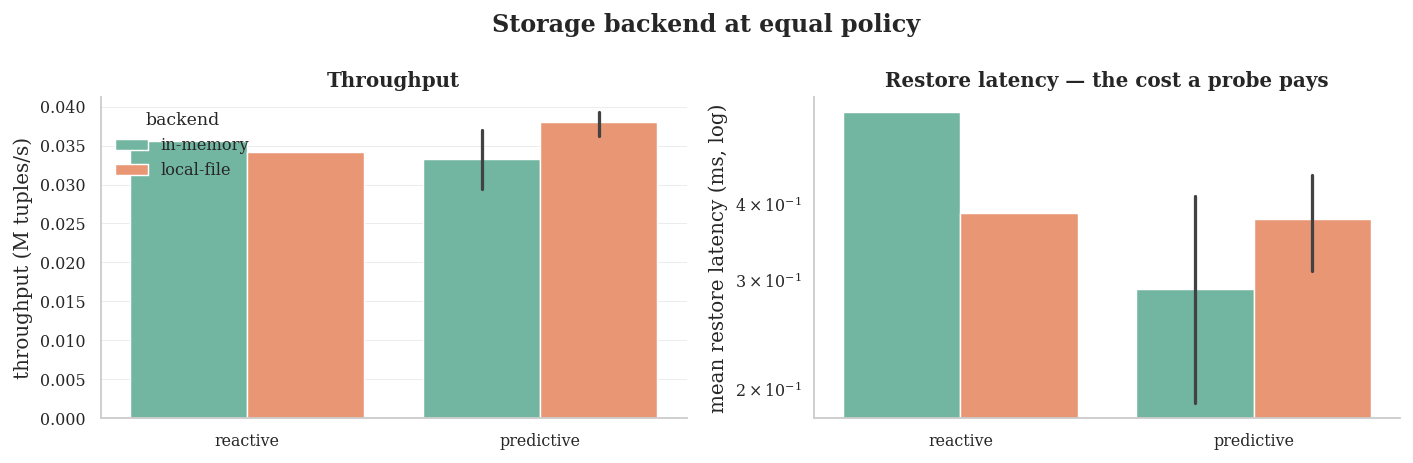

In [10]:
sub = ok[(ok['spill_variant'] != 'off') & ok['avg_throughput_tps'].notna()]
if have(sub, 'backend comparison'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    sns.barplot(data=sub, x='policy', y='tps_M', hue='backend', errorbar=('ci', 95),
                palette='Set2', ax=axes[0])
    axes[0].set_ylabel('throughput (M tuples/s)')
    axes[0].set_xlabel('')
    axes[0].set_title('Throughput')

    lat = sub[sub['avg_restore_latency_ms'].notna() & (sub['total_restores'] > 0)]
    if len(lat):
        sns.barplot(data=lat, x='policy', y='avg_restore_latency_ms', hue='backend',
                    errorbar=('ci', 95), palette='Set2', ax=axes[1])
        axes[1].set_yscale('log')
        axes[1].set_ylabel('mean restore latency (ms, log)')
    else:
        axes[1].text(0.5, 0.5, 'no restores recorded', ha='center', va='center',
                     transform=axes[1].transAxes)
    axes[1].set_xlabel('')
    axes[1].set_title('Restore latency — the cost a probe pays')
    if axes[1].get_legend():
        axes[1].get_legend().remove()
    fig.suptitle('Storage backend at equal policy', fontweight='bold')
    fig.tight_layout()
    save(fig, 'fig_07_backend')
    plt.show()

## 8. Which watermark predictor?

The predictive policy is only as good as the predictor behind it. This is the point where the
end-to-end benchmark meets the predictor microbenchmark: if EWMA and Kalman rank the same here as
they do on the synthetic traces, the microbenchmark is predictive of system behaviour.

wrote results/20260803-152858/fig_08_predictor.png


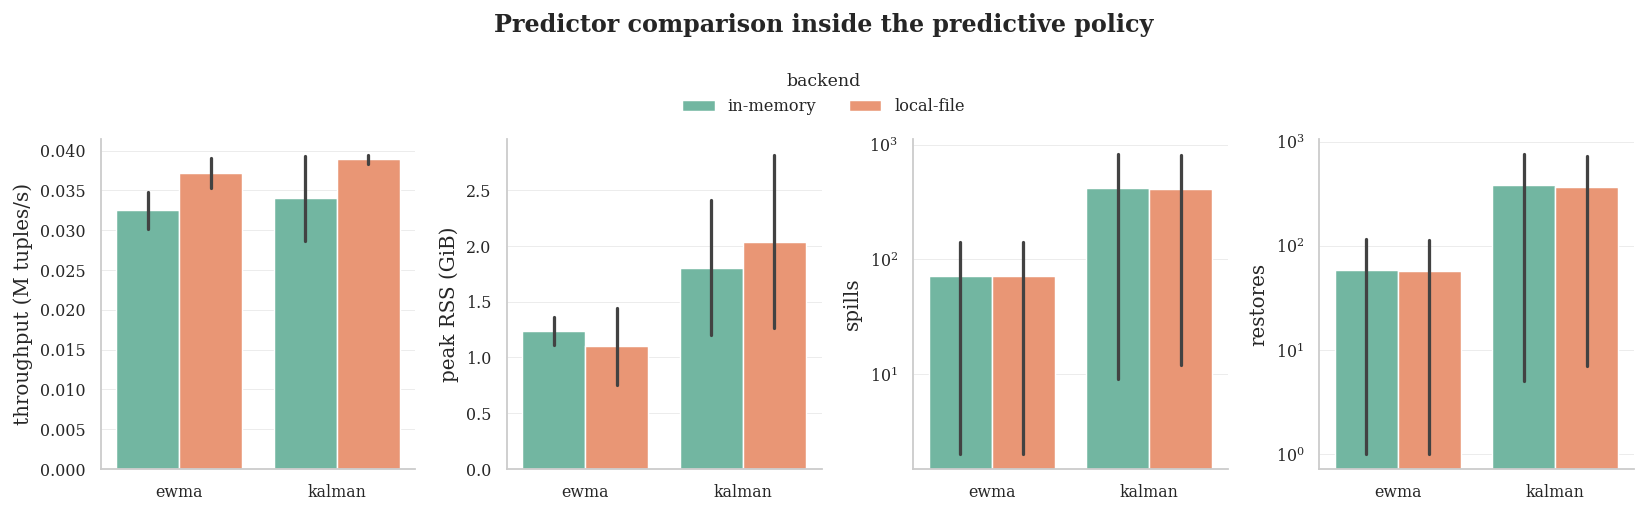

In [11]:
pred = ok[(ok['policy'] == 'predictive') & (ok['predictor'] != '')]
if have(pred, 'predictive cells'):
    panels = [('tps_M', 'throughput (M tuples/s)', False),
              ('peak_rss_gib', 'peak RSS (GiB)', False),
              ('total_spills', 'spills', True),
              ('total_restores', 'restores', True)]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 3.5))
    for ax, (col, label, logy) in zip(axes, panels):
        if pred[col].notna().sum() == 0:
            ax.text(0.5, 0.5, 'n/a', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            continue
        sns.barplot(data=pred, x='predictor', y=col, hue='backend', errorbar=('ci', 95),
                    palette='Set2', ax=ax)
        ax.set_ylabel(label)
        ax.set_xlabel('')
        if logy and pred[col].max() > 0:
            ax.set_yscale('log')
        if ax.get_legend():
            ax.get_legend().remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='backend', loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle('Predictor comparison inside the predictive policy', fontweight='bold', y=1.12)
    fig.tight_layout()
    save(fig, 'fig_08_predictor')
    plt.show()

## 9. Thread scaling

The spill decorator takes a lock per GC tick and the restore path is synchronous, so the question
is whether the spill variants scale as well as `off` or whether the decorator becomes the
bottleneck.

wrote results/20260803-152858/fig_09_scaling.png


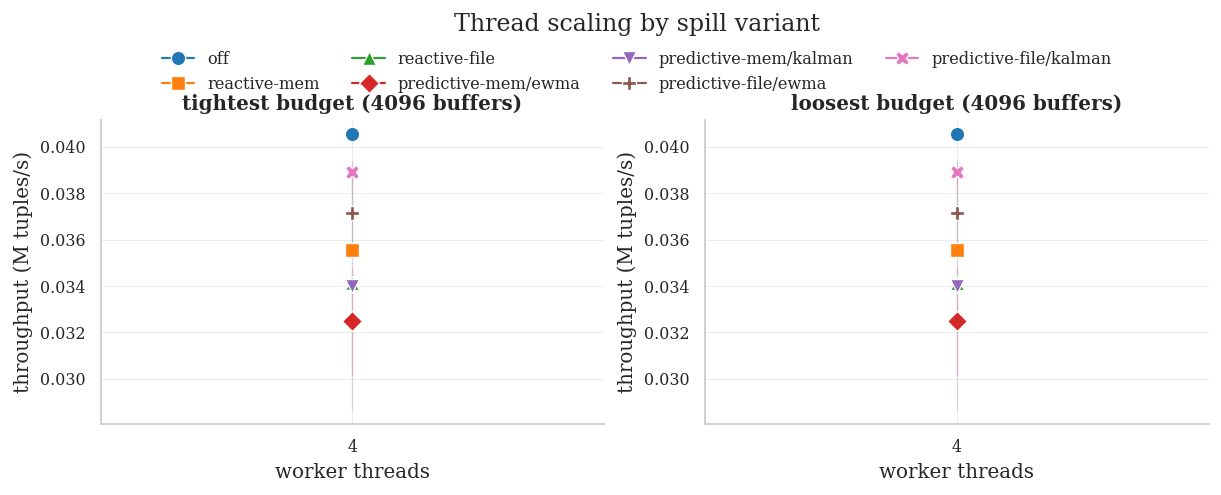

In [12]:
sub = ok[ok['avg_throughput_tps'].notna()]
if have(sub, 'thread scaling'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, budget, name in [(axes[0], min(BUDGETS), 'tightest budget'),
                             (axes[1], max(BUDGETS), 'loosest budget')]:
        s = sub[sub['no_buffers'] == budget]
        sns.lineplot(data=s, x='threads', y='tps_M', hue='variant', style='variant',
                     hue_order=order_for(s), palette=PALETTE, markers=MARKERS, dashes=False,
                     markersize=8, errorbar=('ci', 95), ax=ax)
        ax.set_xticks(THREADS)
        ax.set_xlabel('worker threads')
        ax.set_ylabel('throughput (M tuples/s)')
        ax.set_title(f'{name} ({int(budget)} buffers)')
        if ax.get_legend():
            ax.get_legend().remove()
    legend_top(fig, axes[0], 'Thread scaling by spill variant')
    save(fig, 'fig_09_scaling')
    plt.show()

## 10. Payload size

`var_sized_bytes` sets how much state each slice carries. Bigger payloads mean fewer tuples fit in
the pool, so pressure arrives earlier and each spill moves more bytes — the regime where spilling
should pay off most, and where a bad eviction choice costs most.

wrote results/20260803-152858/fig_10_payload.png


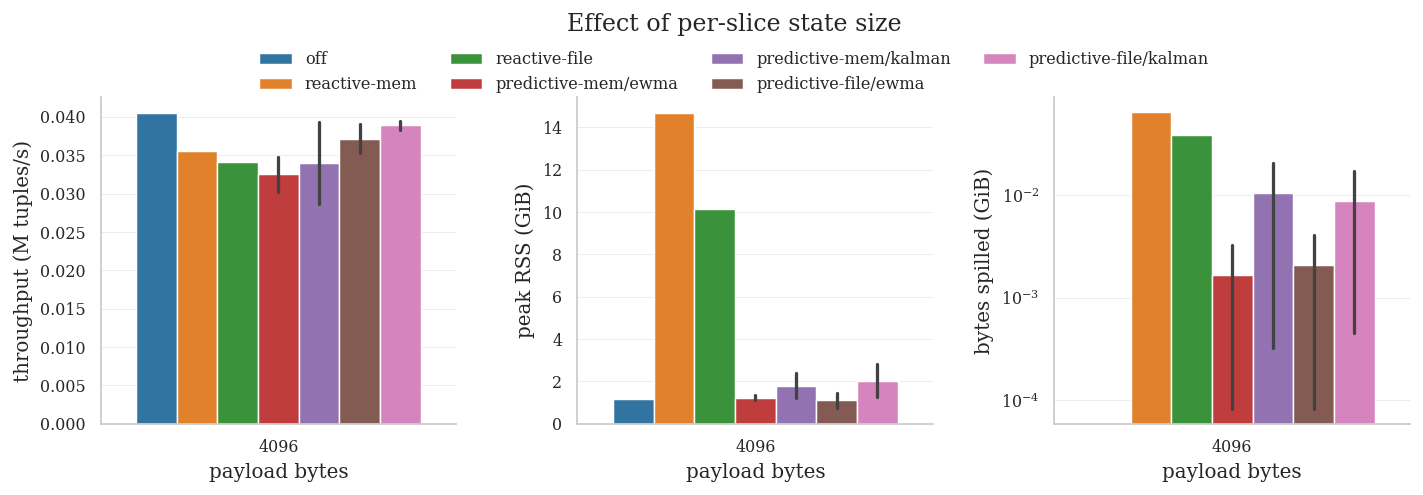

In [13]:
sub = ok[ok['avg_throughput_tps'].notna()]
if have(sub, 'payload sweep'):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, (col, label, logy) in zip(axes, [('tps_M', 'throughput (M tuples/s)', False),
                                             ('peak_rss_gib', 'peak RSS (GiB)', False),
                                             ('spilled_gib', 'bytes spilled (GiB)', True)]):
        if sub[col].notna().sum() == 0 or sub[col].fillna(0).max() == 0:
            ax.text(0.5, 0.5, 'n/a', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            continue
        sns.barplot(data=sub, x='var_sized_bytes', y=col, hue='variant', hue_order=order_for(sub),
                    palette=PALETTE, errorbar=('ci', 95), ax=ax)
        ax.set_xlabel('payload bytes')
        ax.set_ylabel(label)
        if logy:
            ax.set_yscale('log')
        if ax.get_legend():
            ax.get_legend().remove()
    fig.subplots_adjust(wspace=0.34)  # long y-labels need room between narrow panels
    legend_top(fig, axes[0], 'Effect of per-slice state size')
    save(fig, 'fig_10_payload')
    plt.show()

## 11. The whole sweep, relative to no spilling

Every configuration in one view, normalized to its matched `off` cell. Diverging scale centred on
1.0: blue beats the no-spill baseline, red is worse than it. Normalizing to the baseline rather
than to the column maximum is what makes "does this beat not spilling at all?" readable at a glance.

wrote results/20260803-152858/fig_11_heatmap_speedup.png


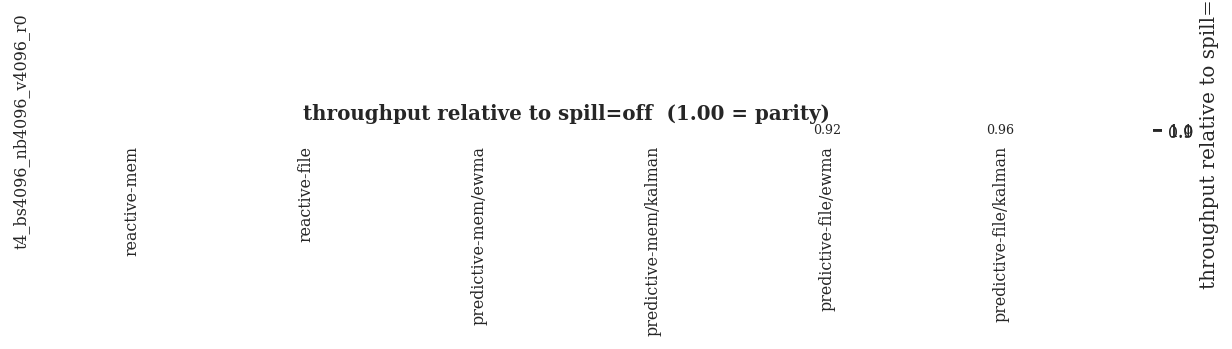

wrote results/20260803-152858/fig_11_heatmap_mem_ratio.png


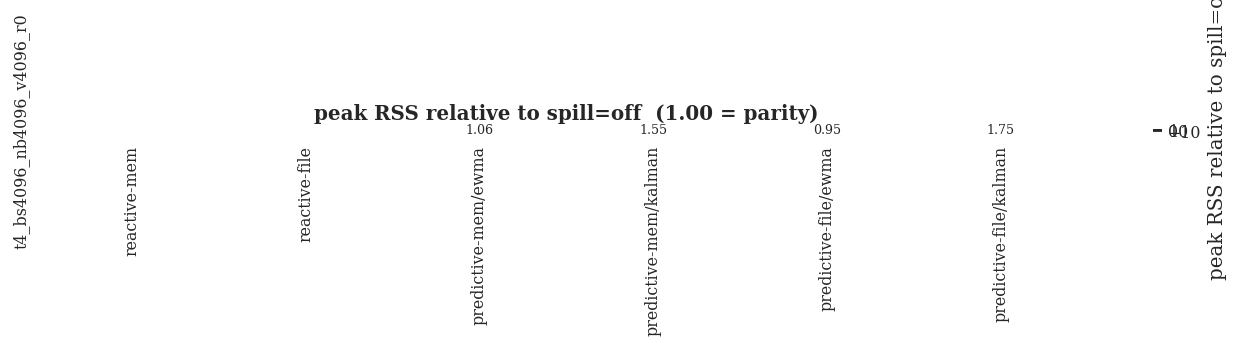

In [14]:
sub = ok[ok['speedup'].notna() & (ok['spill_variant'] != 'off')]
if have(sub, 'baseline-normalized heatmap'):
    ### Row = the non-spill part of the configuration; column = the spill variant.
    sub = sub.assign(config=('t' + sub['threads'].astype('Int64').astype(str)
                             + '_bs' + sub['operator_buffer_size'].astype('Int64').astype(str)
                             + '_nb' + sub['no_buffers'].astype('Int64').astype(str)
                             + '_v' + sub['var_sized_bytes'].astype('Int64').astype(str)
                             + '_r' + sub['ingestion_rate'].astype('Int64').astype(str)))
    for metric, name, cmap in [('speedup', 'throughput relative to spill=off', 'vlag_r'),
                               ('mem_ratio', 'peak RSS relative to spill=off', 'vlag')]:
        pivot = sub.pivot_table(index='config', columns='variant', values=metric, observed=True)
        if pivot.empty:
            continue
        span = float(np.nanmax(np.abs(pivot.to_numpy() - 1.0)))
        norm = TwoSlopeNorm(vmin=1 - span, vcenter=1.0, vmax=1 + span) if span > 0 else None
        fig, ax = plt.subplots(figsize=(1.1 * pivot.shape[1] + 4, 0.32 * len(pivot) + 1.8))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap, norm=norm, linewidths=0.4,
                    annot_kws={'fontsize': 7}, cbar_kws={'label': name}, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{name}  (1.00 = parity)')
        fig.tight_layout()
        save(fig, f'fig_11_heatmap_{metric}')
        plt.show()

## 12. Spill activity — the mechanism

Everything above is an outcome. This is the mechanism: how much the policy actually moved, how
often a probe had to pay a restore, and how long that restore took. A variant whose throughput
looks fine because it never spilled is only visible here.

wrote results/20260803-152858/fig_12_spill_activity.png


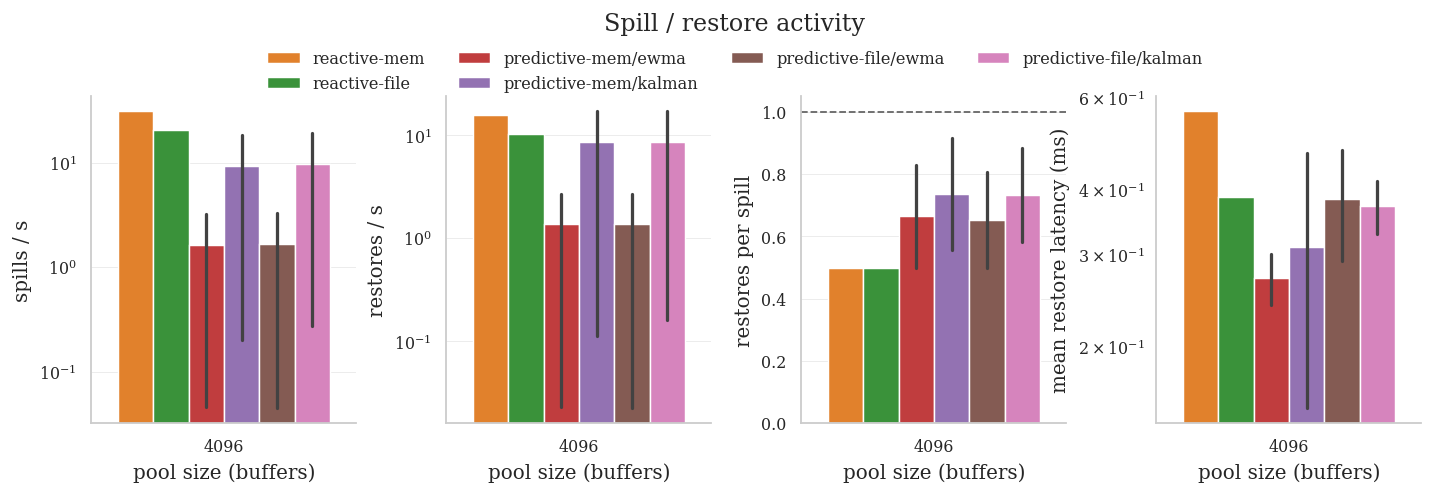

In [15]:
act = ok[(ok['spill_variant'] != 'off') & ok['total_spills'].notna()]
if have(act, 'spill counters'):
    if act['total_spills'].sum() == 0:
        print('WARNING: no cell recorded a single spill — check that memory pressure reached '
              'high_bound (see fig_02: pooled buffers in use vs pool capacity).')
    ### Per-second rates, so cells with different wall times are comparable.
    act = act.assign(spills_per_s=act['total_spills'] / act['wall_s'],
                     restores_per_s=act['total_restores'] / act['wall_s'],
                     restore_frac=np.where(act['total_spills'] > 0,
                                           act['total_restores'] / act['total_spills'], np.nan))
    panels = [('spills_per_s', 'spills / s', True),
              ('restores_per_s', 'restores / s', True),
              ('restore_frac', 'restores per spill', False),
              ('avg_restore_latency_ms', 'mean restore latency (ms)', True)]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.3 * len(panels), 3.6))
    for ax, (col, label, logy) in zip(axes, panels):
        s = act[act[col].notna() & (act[col] > 0)] if logy else act[act[col].notna()]
        if len(s) == 0:
            ax.text(0.5, 0.5, 'n/a', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            continue
        sns.barplot(data=s, x='no_buffers', y=col, hue='variant', hue_order=order_for(s),
                    palette=PALETTE, errorbar=('ci', 95), ax=ax)
        ax.set_xlabel('pool size (buffers)')
        ax.set_ylabel(label)
        if logy:
            ax.set_yscale('log')
        if col == 'restore_frac':
            ### 1.0 = every spilled slice was needed again: the policy evicted exactly wrong.
            ax.axhline(1.0, ls='--', lw=1, color='0.4')
        if ax.get_legend():
            ax.get_legend().remove()
    fig.subplots_adjust(wspace=0.34)  # long y-labels need room between narrow panels
    legend_top(fig, axes[0], 'Spill / restore activity')
    save(fig, 'fig_12_spill_activity')
    plt.show()

## 13. Prediction payoff — the causal claim

The reactive and predictive policies differ in exactly one decision: under pressure, the predictive
one *keeps* a slice whose predicted trigger falls inside the horizon instead of spilling it.
`kept_by_prediction` counts those decisions.

If prediction is what wins, then relative to reactive at the same budget the predictive variants
should show **fewer restores per spill** (they kept the slices that were about to be probed), and
that gap should widen with the horizon. `spilled_predictor_cold` is the honest counterweight: those
are the decisions where the predictor had nothing to say and the policy fell back to reactive
behaviour.

wrote results/20260803-152858/fig_13_prediction_payoff.png


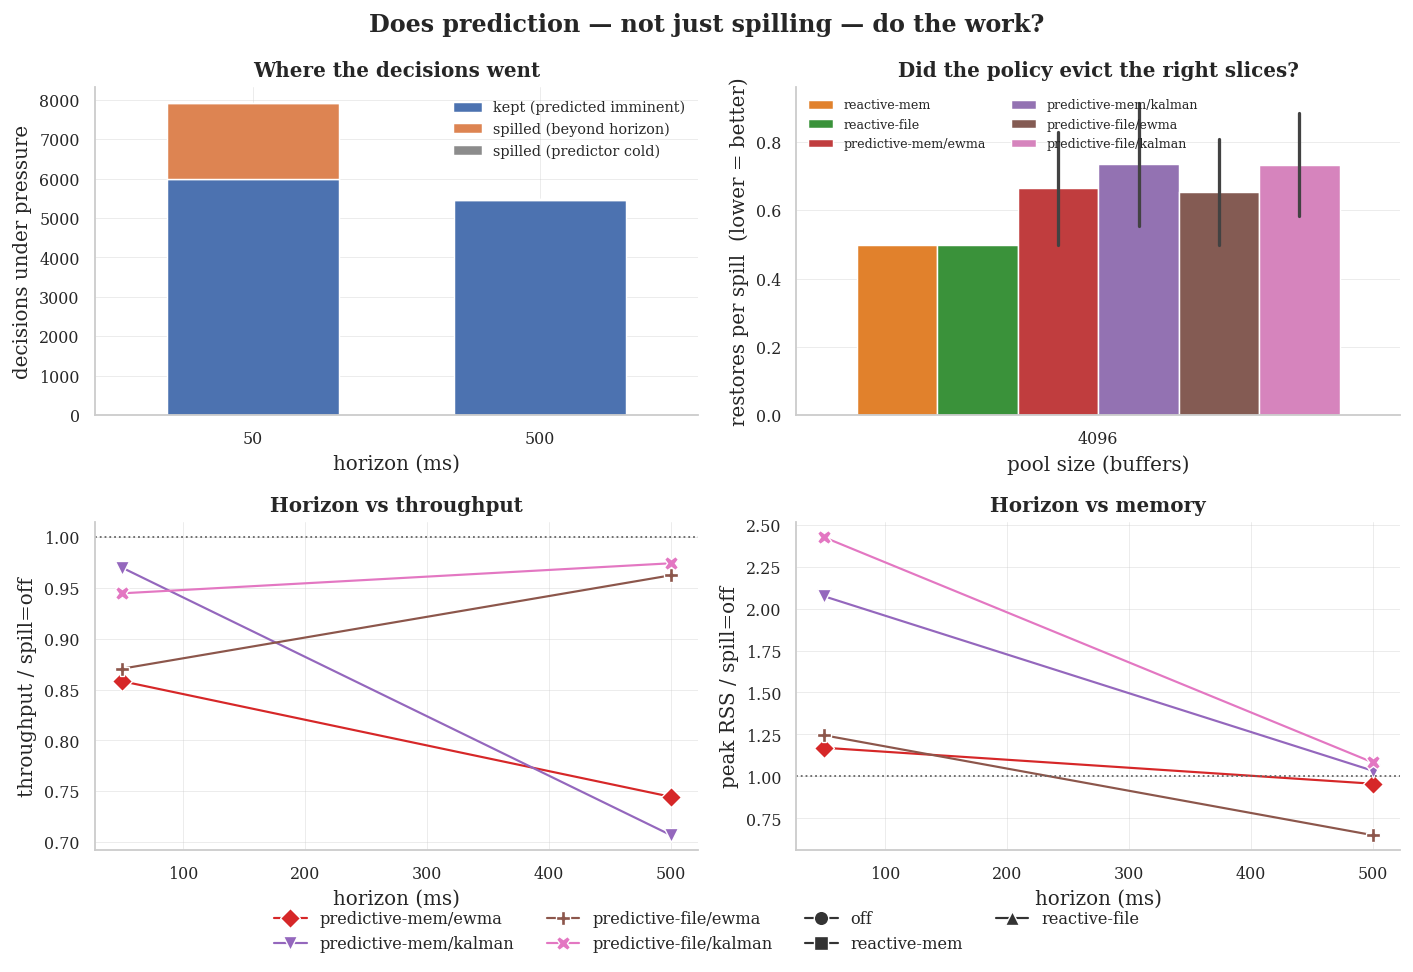

In [16]:
pv = ok[(ok['policy'] == 'predictive') & ok['kept_by_prediction'].notna()]
rv = ok[(ok['policy'] == 'reactive') & ok['total_spills'].notna()]
if have(pv, 'predictive decision counters'):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))

    ### (a) Where the decisions went, per horizon.
    ax = axes[0][0]
    decisions = (pv.groupby('horizon_ms', observed=True)[
        ['kept_by_prediction', 'spilled_beyond_horizon', 'spilled_predictor_cold']].sum())
    if decisions.to_numpy().sum() > 0:
        decisions.plot(kind='bar', stacked=True, ax=ax, width=0.6,
                       color=['#4c72b0', '#dd8452', '#8c8c8c'])
        ax.legend(['kept (predicted imminent)', 'spilled (beyond horizon)',
                   'spilled (predictor cold)'], fontsize=8)
    ax.set_xlabel('horizon (ms)')
    ax.set_ylabel('decisions under pressure')
    ax.set_title('Where the decisions went')
    ax.tick_params(axis='x', rotation=0)

    ### (b) The payoff: restores per spill, predictive vs reactive at the same budget. A restore is a
    ### slice the policy evicted and then immediately needed back — lower is a better eviction choice.
    ax = axes[0][1]
    both = pd.concat([pv, rv])
    both = both[both['total_spills'] > 0].assign(
        restore_frac=lambda d: d['total_restores'] / d['total_spills'])
    if len(both):
        sns.barplot(data=both, x='no_buffers', y='restore_frac', hue='variant',
                    hue_order=order_for(both), palette=PALETTE, errorbar=('ci', 95), ax=ax)
        ax.legend(title='', fontsize=7, ncol=2)
    ax.set_xlabel('pool size (buffers)')
    ax.set_ylabel('restores per spill  (lower = better)')
    ax.set_title('Did the policy evict the right slices?')

    ### (c)/(d) Horizon sensitivity. Throughput and memory are two different measures, so they get two
    ### axes rather than one axes with two scales; both are ratios to the matched spill=off cell.
    hz = pv[pv['speedup'].notna()]
    for ax, col, label in [(axes[1][0], 'speedup', 'throughput / spill=off'),
                           (axes[1][1], 'mem_ratio', 'peak RSS / spill=off')]:
        if hz['horizon_ms'].nunique() > 1 and hz[col].notna().any():
            sns.lineplot(data=hz, x='horizon_ms', y=col, hue='variant', style='variant',
                         hue_order=order_for(hz), palette=PALETTE, markers=MARKERS, dashes=False,
                         markersize=8, errorbar=('ci', 95), ax=ax)
            ax.axhline(1.0, ls=':', lw=1, color='0.4')
            if ax.get_legend():
                ax.get_legend().remove()
        else:
            ax.text(0.5, 0.5, 'sweep PREDICTION_HORIZON_MS\nover at least 2 values',
                    ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('horizon (ms)')
        ax.set_ylabel(label)
        ax.set_title('Horizon vs throughput' if col == 'speedup' else 'Horizon vs memory')

    handles, labels = axes[1][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False,
                   bbox_to_anchor=(0.5, -0.04))
    fig.suptitle('Does prediction — not just spilling — do the work?', fontweight='bold')
    fig.tight_layout()
    save(fig, 'fig_13_prediction_payoff')
    plt.show()

## Summary table

The numbers behind the figures, one row per variant, averaged over the sweep.

In [17]:
cols = {'tps_M': 'mean', 'peak_rss_gib': 'mean', 'speedup': 'mean', 'mem_ratio': 'mean',
        'total_spills': 'sum', 'total_restores': 'sum', 'spilled_gib': 'sum',
        'kept_by_prediction': 'sum', 'avg_restore_latency_ms': 'mean'}
cols = {k: v for k, v in cols.items() if k in ok}
summary = ok.groupby('variant', observed=True).agg({**cols, 'cell_slug': 'count'})
summary = summary.rename(columns={'cell_slug': 'cells'}).round(3)
display(summary)
summary.to_csv(RUN_DIR / 'summary_by_variant.csv')
print('wrote', RUN_DIR / 'summary_by_variant.csv')

,tps_M,peak_rss_gib,speedup,mem_ratio,total_spills,total_restores,spilled_gib,kept_by_prediction,avg_restore_latency_ms,cells
variant,,,,,,,,,,
off,0.041,1.163,1.000,1.000,0,0,0.000,0,NaN,1
reactive-mem,0.036,14.694,0.877,12.637,1362,681,0.066,0,0.565,1
reactive-file,0.034,10.137,0.842,8.719,920,460,0.039,0,0.387,1
predictive-mem/ewma,0.032,1.237,0.801,1.064,143,118,0.003,1086,0.270,2
predictive-mem/kalman,0.034,1.807,0.838,1.554,841,766,0.021,3445,0.310,2
predictive-file/ewma,0.037,1.102,0.917,0.948,143,115,0.004,717,0.384,2
predictive-file/kalman,0.039,2.040,0.960,1.754,825,727,0.018,6212,0.372,2


wrote results/20260803-152858/summary_by_variant.csv
